# **Final Notebook: Baseline Global Feature Model**

In [ ]:
#imports
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LassoCV, ElasticNetCV, LinearRegression, RidgeCV
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from thesis_package.data.loaders import get_eligible_files, load_scores_df
from thesis_package.features.global_feature_extractor import SurgicalFeatureExtractor
from thesis_package.analysis.analysis import loso_correlation_analysis, loso_residual_analysis, permutation_significance_test
from thesis_package.training.evaluation import LOSOEvaluator, EvaluationConfig
from thesis_package.plotting.plotting import plot_panel_a_feature_correlations, plot_panel_b_intercorrelation_heatmap, plot_predicted_vs_true
from thesis_package.plotting.thesis_figures import plot_combined_feature_screening_figure
from thesis_package.models.mlp_regressor import PyTorchMLPEnsemble


In [2]:
# 1. Get the list of paths (Lightweight)
eligible = get_eligible_files(processed_dir="../data/processed/landmark_dataframes2/",
                              vid_name_map_path="../data/scores/vid_name_map.csv",)

# 2. Loop through: Load ONE, Process ONE, Save ROW
all_metrics = []
for vid_id, part_id, path in tqdm(eligible, desc="Global Extraction"):
    # Load raw data (Big DF)
    df_raw = pd.read_pickle(path) 
    
    # Extract features (Result is 1 row)
    extractor = SurgicalFeatureExtractor(df_raw, fps=30, min_disp=0, vel_threshold=30)
    feats = extractor.features_df
    feats["Vid_Name"] = vid_id
    
    all_metrics.append(feats)
    # df_raw is naturally cleared from RAM when the next loop iteration starts

# 3. Combine 1-row results into final table
df_all_metrics = pd.concat(all_metrics, ignore_index=True)

# 4. Merge with scores
df_ratings = load_scores_df("../data/scores/merged_scores.csv")
df_full = pd.merge(df_all_metrics, df_ratings, on="Vid_Name")

Global Extraction: 100%|██████████| 83/83 [00:24<00:00,  3.34it/s]


## Feature Screening

- Correlation of features with scores
- Intercorrelation heatmap

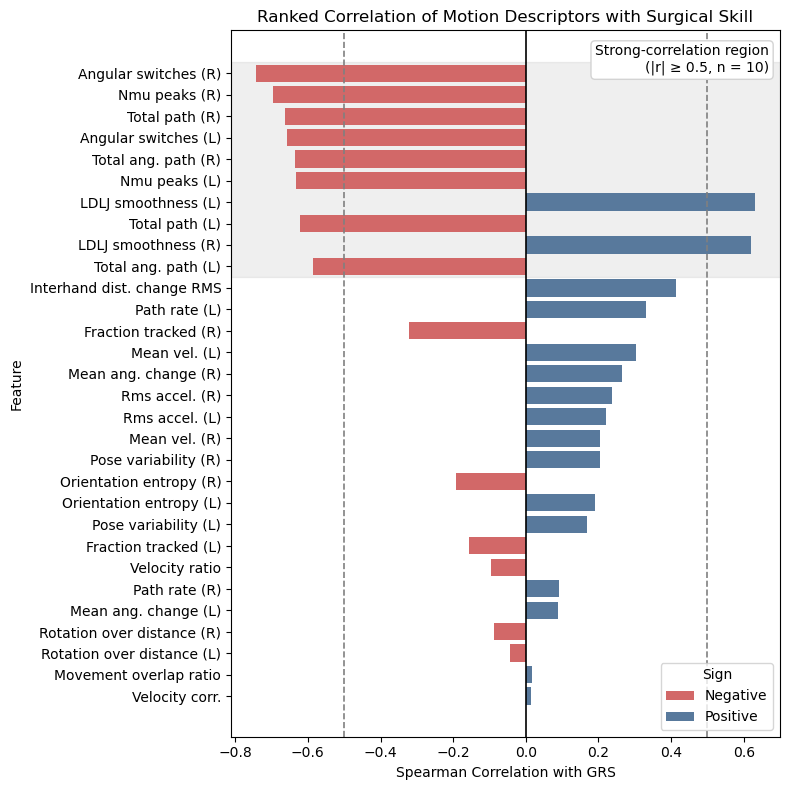

In [3]:
# all hand tracking related features only
all_features = [
    col for col in df_full 
    if col not in df_ratings.columns 
    and col not in ['Total duration (R)', 'Total duration (L)']
]
df_corr = plot_panel_a_feature_correlations(df_full, all_features, target="QRS_Overal")

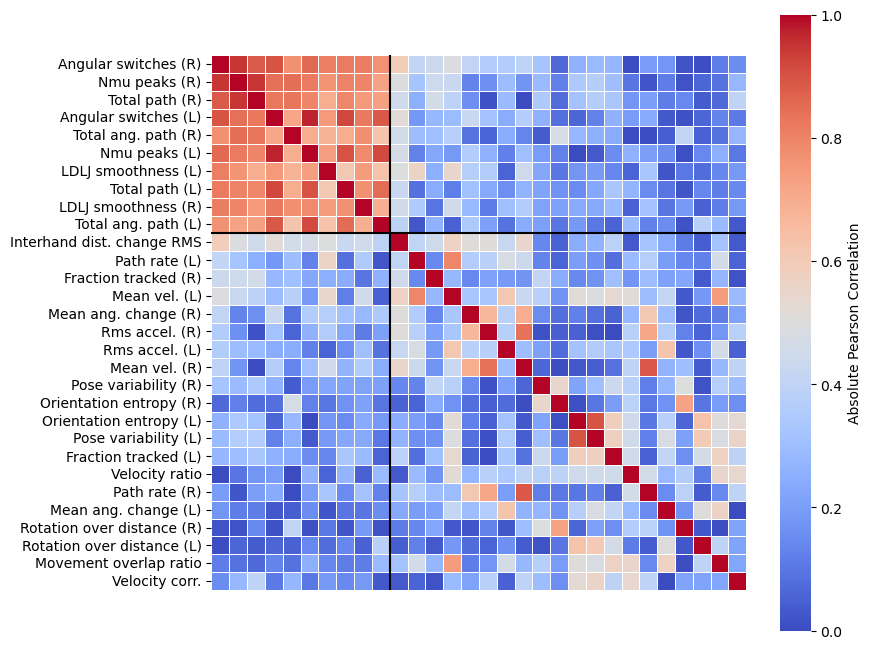

In [4]:
corr_matrix = plot_panel_b_intercorrelation_heatmap(
    df_full,
    df_corr,
    plot_threshold=0.0,
    strong_threshold=0.5
)

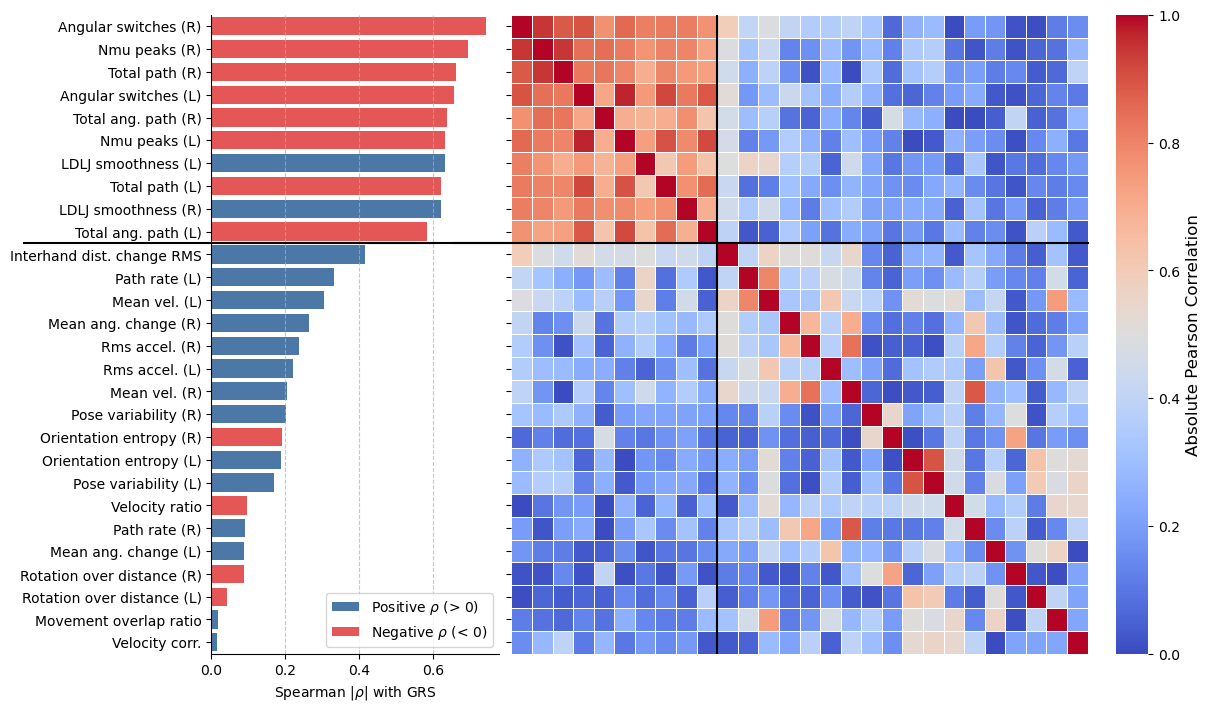

In [5]:
features_plot = [f for f in all_features if not 'Fraction tracked' in f]
df_corr, corr_matrix =plot_combined_feature_screening_figure(
    df_full,
    features_plot,
    target="QRS_Overal",
    strong_threshold=0.5,
    figsize=(12, 7)
)

## Use top Features Only

Extract features that are highly correlated with scores (>0.5) over all folds

In [6]:
# correlation between features and scores
#all_features = [col for col in df_full if col not in df_ratings.columns]
right_features = [col for col in all_features if '(R)' in col]
left_features = [col for col in all_features if '(L)' in col]
bimanual_features = [col for col in all_features if col not in right_features+left_features]

fair_corr_df = loso_correlation_analysis(df_full, all_features, n=61)
fair_corr_df

Analyzing Folds:   0%|          | 0/28 [00:00<?, ?it/s]

Analyzing Folds: 100%|██████████| 28/28 [00:00<00:00, 28.81it/s]


,Feature,Mean_Corr_with_Target,Std_Corr_with_Target,Min_Corr_with_Target,Max_Corr_with_Target,Selection_Stability
1,Angular switches (R),-0.742295,0.013440,-0.789239,-0.727720,1.0
13,Nmu peaks (R),-0.694672,0.015269,-0.742914,-0.679159,1.0
27,Total path (R),-0.662087,0.017930,-0.709668,-0.644378,1.0
0,Angular switches (L),-0.656689,0.015956,-0.692298,-0.627558,1.0
25,Total ang. path (R),-0.635860,0.013361,-0.662923,-0.618964,1.0
12,Nmu peaks (L),-0.631523,0.017098,-0.662818,-0.594263,1.0
5,LDLJ smoothness (L),0.630559,0.015668,0.605905,0.677119,1.0
26,Total path (L),-0.620902,0.018696,-0.659919,-0.582624,1.0
6,LDLJ smoothness (R),0.619828,0.012562,0.597859,0.647380,1.0
24,Total ang. path (L),-0.584263,0.020874,-0.649853,-0.540950,1.0


In [7]:
top_features = fair_corr_df[(abs(fair_corr_df['Min_Corr_with_Target']) > 0.5) & (abs(fair_corr_df['Max_Corr_with_Target']) > 0.5)]['Feature'].tolist()

# top feature intercorrelation
inter_corrs = df_full[top_features].corr()


top_features_right = [feat for feat in top_features if '(R)' in feat]
top_features_left = [feat for feat in top_features if '(L)' in feat]

In [8]:
top_features_right

['Angular switches (R)',
 'Nmu peaks (R)',
 'Total path (R)',
 'Total ang. path (R)',
 'LDLJ smoothness (R)']

# Try Some Models with these Features
- using all features
- using only the top correlated features

In [9]:
def print_performance(results, title):
    summary = results['summary']
    print(f"=== {title} Results ===")
    print(f"MAE: {summary['MAE']:.4f} ± {summary['MAE_STD']:.4f}")
    print(f"Spearman R:{summary['Spearman_R']:.4f} and R²: {summary['R2']:.4f}\n")

In [10]:
evaluator = LOSOEvaluator(EvaluationConfig(
    target_col="QRS_Overal",
    surgeon_col="Participant Number",
    video_col="video_id",
    device="cpu",
    seed=42,
))

In [ ]:
# lasso with all features
lasso_results = evaluator.evaluate_tabular(
    df=df_full,
    primary_features=all_features,
    model=LassoCV(alphas=np.logspace(-1, 0.5, 20)),
)

print_performance(lasso_results, "LassoCV with All Features")

# lasso with top features only
lasso_results = evaluator.evaluate_tabular(
    df=df_full,
    primary_features=top_features,
    model=LassoCV(alphas=np.logspace(-1, 0.5, 20)),
)

print_performance(lasso_results, "LassoCV with Top Features Only")

# linear regression with single top feature only
lr_results = evaluator.evaluate_tabular(
    df=df_full,
    primary_features=['Angular switches (R)'],
    model=LinearRegression(),
)
print_performance(lr_results, "Linear Regression with Angular switches (R) Only")

# random forest with top features only
ridge_results = evaluator.evaluate_tabular(
    df=df_full,
    primary_features=top_features,
    model=RandomForestRegressor(),
)
print_performance(ridge_results, "Random Forest Top Features")

Tabular CV: 100%|██████████| 28/28 [00:01<00:00, 15.11it/s]


=== LassoCV with All Features Results ===
MAE: 5.6987 ± 4.2939
Spearman R:0.6607 and R²: 0.4124



Tabular CV: 100%|██████████| 28/28 [00:00<00:00, 31.62it/s]


=== LassoCV with Top Features Only Results ===
MAE: 5.6492 ± 4.3465
Spearman R:0.6543 and R²: 0.4136



Tabular CV: 100%|██████████| 28/28 [00:00<00:00, 84.75it/s]


=== Linear Regression with Angular switches (R) Only Results ===
MAE: 5.3695 ± 4.1854
Spearman R:0.7249 and R²: 0.4650



Tabular CV: 100%|██████████| 28/28 [00:04<00:00,  6.22it/s]

=== Random Forest Top Features Results ===
MAE: 5.5747 ± 4.3551
Spearman R:0.6487 and R²: 0.4224



In [12]:
# with duration only (which doesn't rely on hand tracking)
ridge_results = evaluator.evaluate_tabular(
    df=df_full,
    primary_features=['Total duration (R)'],
    model=LinearRegression(),
)
print_performance(ridge_results, "Linear Regression with Total Duration Only")

Tabular CV: 100%|██████████| 28/28 [00:00<00:00, 46.41it/s]

=== Linear Regression with Total Duration Only Results ===
MAE: 5.7442 ± 4.1098
Spearman R:0.6856 and R²: 0.4242



# All Top Features are Highly Inter-Correlated
Explore different ways of combining the top correlated features

- Combine all of them with PCA, in one component PC1
- Combine only right features in PC1
- Combine both right and left features in separate right_PC1 + left_PC1

In [13]:
inter_corrs

,Angular switches (R),Nmu peaks (R),Total path (R),Angular switches (L),Total ang. path (R),Nmu peaks (L),LDLJ smoothness (L),Total path (L),LDLJ smoothness (R),Total ang. path (L)
Angular switches (R),1.000000,0.947856,0.886434,0.896690,0.773418,0.855630,-0.811619,0.816461,-0.815964,0.768967
Nmu peaks (R),0.947856,1.000000,0.946420,0.840396,0.847045,0.818757,-0.763363,0.803458,-0.800735,0.725515
Total path (R),0.886434,0.946420,1.000000,0.825805,0.829882,0.797656,-0.698809,0.793139,-0.747065,0.730593
Angular switches (L),0.896690,0.840396,0.825805,1.000000,0.717553,0.972519,-0.747190,0.920183,-0.821330,0.889546
Total ang. path (R),0.773418,0.847045,0.829882,0.717553,1.000000,0.696750,-0.681598,0.697987,-0.774133,0.627234
Nmu peaks (L),0.855630,0.818757,0.797656,0.972519,0.696750,1.000000,-0.737335,0.900756,-0.787495,0.917555
LDLJ smoothness (L),-0.811619,-0.763363,-0.698809,-0.747190,-0.681598,-0.737335,1.000000,-0.611928,0.745644,-0.630422
Total path (L),0.816461,0.803458,0.793139,0.920183,0.697987,0.900756,-0.611928,1.000000,-0.772425,0.847662
LDLJ smoothness (R),-0.815964,-0.800735,-0.747065,-0.821330,-0.774133,-0.787495,0.745644,-0.772425,1.000000,-0.694233
Total ang. path (L),0.768967,0.725515,0.730593,0.889546,0.627234,0.917555,-0.630422,0.847662,-0.694233,1.000000


In [14]:
# with all top features
scaler = StandardScaler()
X = scaler.fit_transform(df_full[top_features].values)

pca = PCA(n_components=len(top_features))
pca.fit(X)
components = pca.components_
explained_variance = pca.explained_variance_ratio_

df = pd.DataFrame(components, columns=top_features)
df['Explained_Variance'] = explained_variance
print('PC1 explained variance:', explained_variance[0])

PC1 explained variance: 0.816643464410691


In [15]:
# right features only
scaler = StandardScaler()
X = scaler.fit_transform(df_full[top_features_right].values)

pca_r = PCA(n_components=len(top_features_right))
pca_r.fit(X)
components = pca_r.components_
explained_variance = pca_r.explained_variance_ratio_

df = pd.DataFrame(components, columns=top_features_right)
df['Explained_Variance'] = explained_variance
print('PC1 explained variance (right features):', explained_variance[0])
pc1_right = pca_r.transform(X)[:, 0]

# left features only
scaler = StandardScaler()
X = scaler.fit_transform(df_full[top_features_left].values)

pca_l = PCA(n_components=len(top_features_left))
pca_l.fit(X)
components = pca_l.components_
explained_variance = pca_l.explained_variance_ratio_
df = pd.DataFrame(components, columns=top_features_left)
df['Explained_Variance'] = explained_variance
print('PC1 explained variance (left features):', explained_variance[0])
pc1_left = pca_l.transform(X)[:, 0]

# corrlation between right and left PC1
correlation = pd.Series(pc1_right).corr(pd.Series(pc1_left))
print('Correlation between right and left PC1:', correlation)

PC1 explained variance (right features): 0.8705575142766632
PC1 explained variance (left features): 0.8583700381604927
Correlation between right and left PC1: 0.8879786905254285


Text(0, 0.5, 'Skill Score')

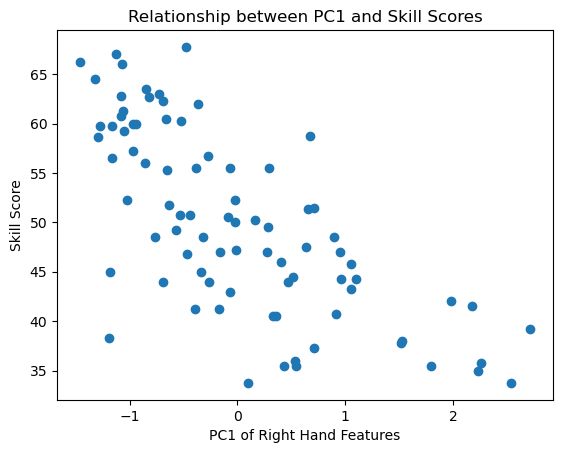

In [21]:
# plot relationship pc1 vs scores
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
scaler = StandardScaler()
plt.scatter(scaler.fit_transform(pc1_right.reshape(-1, 1)), df_full['QRS_Overal'])
plt.title('Relationship between PC1 and Skill Scores')
plt.xlabel('PC1 of Right Hand Features')
plt.ylabel('Skill Score')

## Models With PCA features
- All top features in PC1
- Top right hand features in PC1

In [22]:
ridge_results = evaluator.evaluate_tabular(
    df=df_full,
    primary_features=top_features,
    extra_features=None,
    model=RidgeCV(alphas=np.logspace(-1, 0.5, 20)),
    pca_components=[0],
    collect_weights=True,
)
print_performance(ridge_results, "RidgeCV with PCA on Top Features")
print(ridge_results['weights'])

Tabular CV:   0%|          | 0/28 [00:00<?, ?it/s]

Tabular CV: 100%|██████████| 28/28 [00:01<00:00, 27.31it/s]

=== RidgeCV with PCA on Top Features Results ===
MAE: 5.4643 ± 3.9245
Spearman R:0.6994 and R²: 0.4776

  Feature  Average_Weight  Std_Weight
0    bias       49.938586    0.308361
1     PC1       -6.524203    0.161776


In [23]:
ridge_results = evaluator.evaluate_tabular(
    df=df_full,
    primary_features=top_features_right,
    extra_features=None,
    model=RidgeCV(alphas=np.logspace(-1, 0.5, 20)),
    pca_components=[0],
    collect_weights=True,
)
print_performance(ridge_results, "RidgeCV with PCA on Right Top Features")
print(ridge_results['weights'])

Tabular CV: 100%|██████████| 28/28 [00:00<00:00, 44.61it/s]


=== RidgeCV with PCA on Right Top Features Results ===
MAE: 5.3522 ± 4.1120
Spearman R:0.6925 and R²: 0.4742

  Feature  Average_Weight  Std_Weight
0    bias       49.938586    0.308361
1     PC1       -6.487758    0.163772


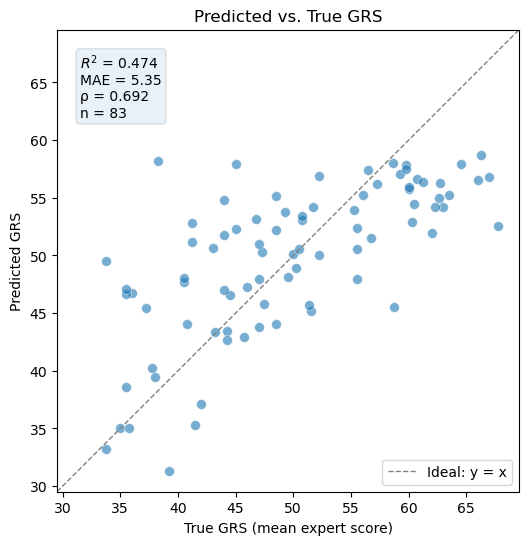

In [24]:
_, _ = plot_predicted_vs_true(ridge_results['predictions'], 
                       show_group_labels=False, 
                       add_fit_line=False)

The performance is comparable. Since all participants are right hand dominant, and the first principal component of the top right features only pca captures more varaince this approach is prefered and used as the baseline efficiency feature.

## How Well Do the Remaining Features Explain the Residuals of PC1 only Ridge Model?

In [11]:
# right features only in pc1
candidate_features = [feat for feat in all_features if feat not in top_features_right]

df_res_leakage_free = loso_residual_analysis(df_full, top_features_right, candidate_features=candidate_features, top_n=1, test_other_pcs=True)
df_res_leakage_free

,Feature,Partial_R2_mean,Partial_R2_std,Partial_R2_min,Resid_Corr_mean,Selection_Stability
27,Velocity corr.,0.105394,0.015926,0.050750,-0.305225,0.964286
28,Velocity ratio,0.038402,0.010849,0.014265,-0.194587,0.000000
4,LDLJ smoothness (L),0.030263,0.011788,0.010420,0.121595,0.035714
21,Rms accel. (L),0.026153,0.007404,0.004096,-0.144498,0.000000
6,Mean ang. change (R),0.025603,0.006420,0.013692,0.161108,0.000000
19,Pose variability (L),0.017554,0.006519,0.003695,-0.118642,0.000000
1,Fraction tracked (L),0.016324,0.005731,0.005611,0.115784,0.000000
23,Rotation over distance (L),0.015272,0.008029,0.004285,-0.123909,0.000000
12,Orientation entropy (R),0.013554,0.004990,0.002425,-0.118484,0.000000
16,PCA_Comp_5,0.013499,0.005139,0.002862,0.118799,0.000000


### Hybrid Model PC1 + Velocity Corr

Clear imporvement! 

In [12]:
ridge_results = evaluator.evaluate_tabular(
    df=df_full,
    primary_features=top_features_right,
    extra_features=['Velocity corr.'],
    model=RidgeCV(alphas=np.logspace(-1, 0.5, 20)),
    pca_components=[0],
    collect_weights=True,
)
print_performance(ridge_results, "RidgeCV with Right PC1 + Velocity Corr.")
print(ridge_results['weights'])

Tabular CV: 100%|██████████| 28/28 [00:01<00:00, 21.13it/s]


=== RidgeCV with Right PC1 + Velocity Corr. Results ===
MAE: 5.2511 ± 3.8473
Spearman R:0.7230 and R²: 0.5109

          Feature  Average_Weight  Std_Weight
0            bias       49.938586    0.308361
1             PC1       -7.114179    0.181956
2  Velocity corr.       -2.146442    0.192894


**Interpretation negative velocity correlation weight**

The Novice (High Correlation): Often moves both hands in a "mirroring" or "coupled" fashion because they lack the independent motor control to perform different tasks with each hand. When they move the right hand to pull a thread, the left hand "sympathetically" moves or trembles in the same direction.

The Expert (Lower Correlation): Experts exhibit bimanual functional dissociation. One hand is perfectly still (providing counter-traction) while the other hand moves at high speed. Or, one hand moves left while the other moves up. Their velocity profiles are uncoupled because their hands have specialized roles.

## Statistical Significance?

Running 300 permutations...


100%|██████████| 300/300 [31:10<00:00,  6.23s/it]



--- Significance Results ---
Real Partial R2: 0.1054
Empirical p-value: 0.1400
Z-score vs Null: 1.11


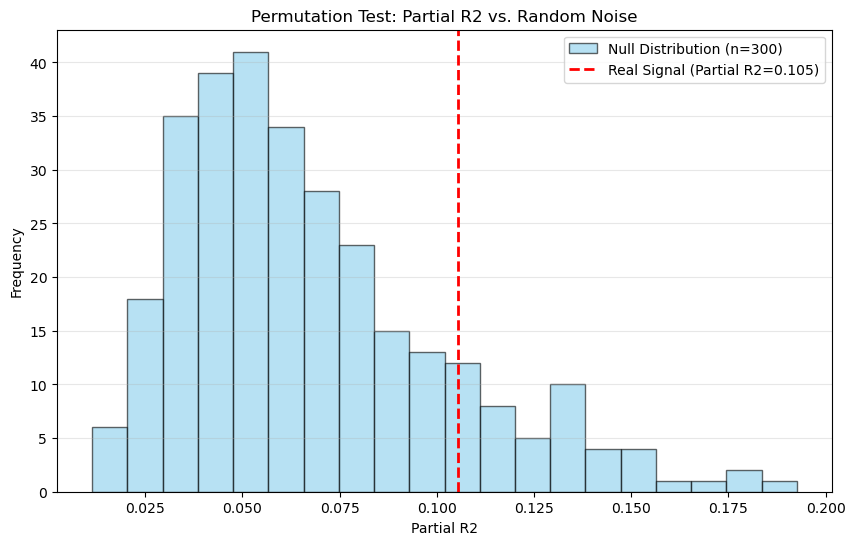

In [13]:
real_signal = df_res_leakage_free['Partial_R2_mean'].values[0]

# 2. Run the test
results = permutation_significance_test(
    df=df_full,
    top_features_right=top_features_right,
    candidate_features=candidate_features,
    real_val=real_signal,
    n_shuffles=300,
    show_plot=True
)

# Take Different Cases into account

- With Dummy Case variable
- By standarizing the relevant features by case

In [19]:
# one hot encode Case_Number
df_case_onehot = pd.get_dummies(df_full['Case_Number'], prefix='Case').astype(int)

if not any('Case_1' in col for col in df_full.columns):
    df_full = pd.concat([df_full, df_case_onehot], axis=1)

In [20]:
candidate_features = list(set(candidate_features + list(df_case_onehot.columns)))
df_res_leakage_free = loso_residual_analysis(df_full, top_features_right, candidate_features, base_features=['Case_1', 'Case_2', 'Case_3'], top_n=1, test_other_pcs=True)
df_res_leakage_free

,Feature,Partial_R2_mean,Partial_R2_std,Partial_R2_min,Resid_Corr_mean,Selection_Stability
30,Velocity corr.,0.067437,0.013466,0.022095,-0.223426,0.892857
24,Rms accel. (L),0.046501,0.010152,0.014641,-0.180292,0.035714
4,Fraction tracked (L),0.028318,0.006535,0.015272,0.131108,0.000000
15,Orientation entropy (R),0.026486,0.006661,0.011877,-0.149475,0.000000
8,Mean ang. change (L),0.026402,0.007708,0.007681,-0.128556,0.000000
11,Mean vel. (R),0.025506,0.009343,0.006418,-0.093084,0.000000
26,Rotation over distance (L),0.022513,0.010720,0.011915,-0.133576,0.035714
12,Movement overlap ratio,0.018845,0.008680,0.002529,-0.122069,0.000000
31,Velocity ratio,0.017553,0.007405,0.001992,-0.116781,0.000000
7,LDLJ smoothness (L),0.014828,0.008942,-0.000307,0.107232,0.035714


In [21]:
ridge_results = evaluator.evaluate_tabular(
    df=df_full,
    primary_features=top_features_right,
    extra_features=['Case_1', 'Case_2', 'Case_3'],
    model=RidgeCV(alphas=np.logspace(-1, 0.5, 20)),
    pca_components=[0],
    collect_weights=True,
    verbose=False,
)
print_performance(ridge_results, "Ridge with Right PC1 + Case Type Dummies")
print(ridge_results['weights'])

=== Ridge with Right PC1 + Case Type Dummies Results ===
MAE: 5.2231 ± 3.9821
Spearman R:0.7165 and R²: 0.5021

  Feature  Average_Weight  Std_Weight
0    bias       49.967973    0.307077
1     PC1       -6.387588    0.156692
2  Case_1       -1.697590    0.108038
3  Case_2       -0.733910    0.175705
4  Case_3        2.431500    0.152522


In [40]:
# For comparison 
# duration and case types which don't rely on hand tracking at all
ridge_results = evaluator.evaluate_tabular(
    df=df_full,
    primary_features=['Total duration (R)'],
    extra_features=['Case_1', 'Case_2', 'Case_3'],
    model=RidgeCV(alphas=np.logspace(-1, 0.5, 20)),
    collect_weights=True,
    verbose=False,
)
print_performance(ridge_results, "Ridge with Total duration + Case Type Dummies")
print(ridge_results['weights'])

=== Ridge with Total duration + Case Type Dummies Results ===
MAE: 5.7728 ± 4.1473
Spearman R:0.6591 and R²: 0.4168

              Feature  Average_Weight  Std_Weight
0                bias       49.950659    0.307814
1  Total duration (R)       -5.985334    0.159181
2              Case_1       -0.997163    0.113314
3              Case_2        0.001917    0.176877
4              Case_3        0.995246    0.160609


## **NN Model**



In [ ]:
mlp = PyTorchMLPEnsemble(input_dim=4,
                           hidden_dim=16,
                           n_hidden=1,
                           n_models=5,
                           dropout=0.15,
                           batch_size=16)

mlp_results = evaluator.evaluate_tabular(
    df=df_full,
    primary_features=right_features,
    extra_features=['Case_1', 'Case_2', 'Case_3'],
    model=mlp,
    pca_components=[0],
    selector=None,
    scale_target=True,
    primary_feature_corr_threshold=0.5,
    verbose=False,
    print_fold_metrics=True
)

print_performance(mlp_results, "MLP with Right PC1 + Case Type Dummies")

Fold 1 - Test Group [np.int64(1)]: Test MAE: 6.1022, Train MAE: 4.5306, N primary: 5
Fold 2 - Test Group [np.int64(2)]: Test MAE: 3.6291, Train MAE: 4.6402, N primary: 5
Fold 3 - Test Group [np.int64(3)]: Test MAE: 8.2315, Train MAE: 4.5329, N primary: 5
Fold 4 - Test Group [np.int64(4)]: Test MAE: 3.9739, Train MAE: 4.6416, N primary: 5
Fold 5 - Test Group [np.int64(5)]: Test MAE: 6.2051, Train MAE: 4.5875, N primary: 5
Fold 6 - Test Group [np.int64(6)]: Test MAE: 1.3612, Train MAE: 4.7206, N primary: 5
Fold 7 - Test Group [np.int64(7)]: Test MAE: 9.6985, Train MAE: 4.4135, N primary: 5
Fold 8 - Test Group [np.int64(9)]: Test MAE: 3.1793, Train MAE: 4.7005, N primary: 5
Fold 9 - Test Group [np.int64(10)]: Test MAE: 3.7834, Train MAE: 4.6866, N primary: 5
Fold 10 - Test Group [np.int64(11)]: Test MAE: 1.8894, Train MAE: 4.7357, N primary: 5
Fold 11 - Test Group [np.int64(12)]: Test MAE: 4.9182, Train MAE: 4.6705, N primary: 5
Fold 12 - Test Group [np.int64(13)]: Test MAE: 2.7524, Train

try MLPs with PC1 + velocity_corr + other_features(s)